# GAIA LV1 – Plan-Template Reuse Analysis

Compares four execution conditions on the 51 GAIA Level-1 test tasks:

| Condition | Description |
|-----------|-------------|
| **Baseline** | Agent plans freely (`gaia_lv1_x4`, `paraphrase_index=0` only) |
| **Rank-by-Steps** | Plan template ranked by fewest tool calls |
| **Rank-by-Tokens** | Plan template ranked by fewest tokens |
| **Rank-by-Latency** | Plan template ranked by lowest latency |

All three reuse conditions share the same KB (`gaia_lv1_x4` paraphrases, `paraphrase_index≥1`),
the same retrieval threshold (cosine ≥ 0.8, top-5 neighbours), and the same prompt except
for the injected plan template — making the template the sole independent variable.

In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Resolve repo root whether the kernel cwd is notebooks/ or the repo root itself
_cwd = Path(".").resolve()
REPO_ROOT  = _cwd.parent if _cwd.name == "notebooks" else _cwd
TRACE_ROOT = REPO_ROOT / "traces" / "claude_native"

CONDS = {
    "Baseline":        ("gaia_lv1_x4",                         False),
    "Rank-by-Steps":   ("gaia_lv1_plan_reuse_rank_by_step",    True),
    "Rank-by-Tokens":  ("gaia_lv1_plan_reuse_rank_by_token",   True),
    "Rank-by-Latency": ("gaia_lv1_plan_reuse_rank_by_latency", True),
}
COND_ORDER  = list(CONDS.keys())
COND_COLORS = dict(zip(COND_ORDER, ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]))
INFRA_TOOLS = {"ToolSearch"}  # excluded from plan sequences by the runner

METRIC_META = {
    "total_tool_calls": ("Tool-call savings", "# tool calls", 1),
    "total_tokens":     ("Token savings",     "tokens (K)",   1000),
    "total_latency_ms": ("Latency savings",   "time (s)",     1000),
}
REUSE_CONDS = COND_ORDER[1:]

test_ids = {json.loads(l)["task_id"]
            for l in (REPO_ROOT / "data" / "gaia" / "gaia_lv1.jsonl").open()}
print(f"Repo root : {REPO_ROOT}")
print(f"Test set  : {len(test_ids)} tasks")

Repo root : /work/pi_rsitaram_umass_edu/tungi/ekb-claude-pilot
Test set  : 51 tasks


## Data Loading

In [2]:
def load_traces(run_name, is_reuse):
    out = {}
    for d in sorted((TRACE_ROOT / run_name).iterdir()):
        if not d.is_dir():
            continue
        if not is_reuse and d.name not in test_ids:
            continue
        tf = d / "normalized_trace.json"
        if tf.exists():
            t = json.loads(tf.read_text())
            out[t["query_id"]] = t
    return out

raw = {cond: load_traces(run, ir) for cond, (run, ir) in CONDS.items()}

rows = []
for cond, traces in raw.items():
    for qid in test_ids:
        t = traces.get(qid)
        rows.append({
            "condition":        cond,
            "query_id":         qid,
            "has_trace":        t is not None,
            "success":          bool(t.get("success"))            if t else False,
            "exact_match":      t.get("exact_match")              if t else False,
            "total_tool_calls": t.get("total_tool_calls")         if t else None,
            "total_tokens":     t.get("total_tokens")             if t else None,
            "total_latency_ms": t.get("total_latency_ms")         if t else None,
            "cache_hit":        t.get("cache_hit")                if t else None,
            "cache_similarity": t.get("cache_source_similarity")  if t else None,
            "cache_source_id":  t.get("cache_source_task_id")     if t else None,
            "cached_seq":       t.get("cached_tool_sequence")     if t else None,
            "steps":            t.get("steps", [])                if t else [],
        })

df = pd.DataFrame(rows)
df["condition"] = pd.Categorical(df["condition"], categories=COND_ORDER, ordered=True)
N = len(test_ids)

summary = (df.groupby("condition", observed=True)
             .agg(n_traces=("has_trace", "sum"),
                  n_success=("success", "sum"),
                  n_exact=("exact_match", "sum"))
             .reindex(COND_ORDER))
print(summary)

                 n_traces  n_success  n_exact
condition                                    
Baseline               51         51       43
Rank-by-Steps          49         49       36
Rank-by-Tokens         51         51       41
Rank-by-Latency        49         49       38


## Analysis 1 – Success Rate

"Success" = Claude returned an answer (regardless of correctness).
Tasks that timed out are counted as failures (denominator = 51 for all conditions).

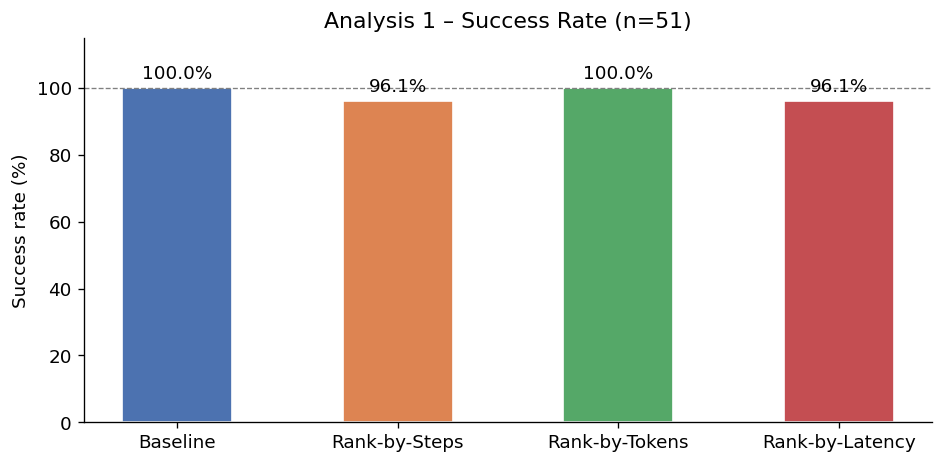

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
rates = [(c, df.loc[df["condition"]==c, "success"].sum() / N * 100) for c in COND_ORDER]
bars  = ax.bar([r[0] for r in rates], [r[1] for r in rates],
               color=[COND_COLORS[r[0]] for r in rates], width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_ylim(0, 115); ax.axhline(100, ls="--", lw=0.8, color="grey")
ax.set_ylabel("Success rate (%)"); ax.set_title("Analysis 1 – Success Rate (n=51)")
plt.tight_layout(); plt.show()

## Analysis 2 – Exact Match Accuracy

Normalised exact match: case-fold, whitespace-strip, numeric canonicalisation.
Missing traces (timeouts) treated as incorrect (denominator = 51).

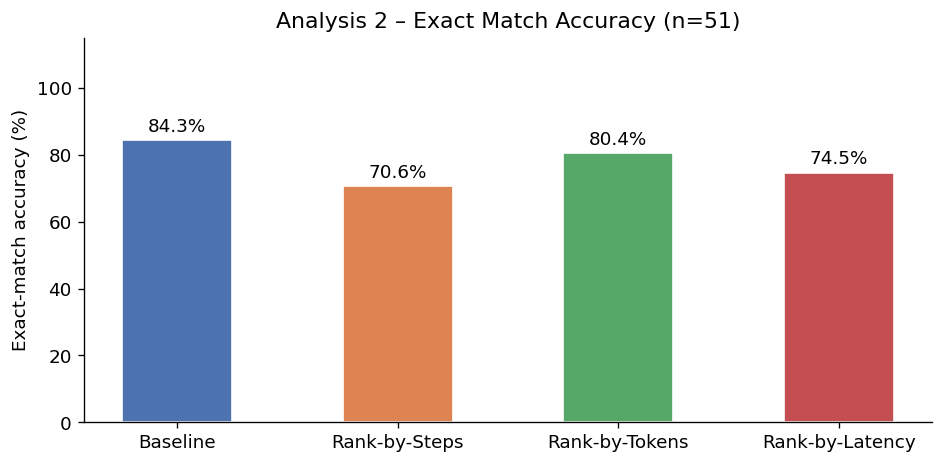

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
rates = [(c, df.loc[df["condition"]==c, "exact_match"]
              .fillna(False).astype(bool).sum() / N * 100) for c in COND_ORDER]
bars  = ax.bar([r[0] for r in rates], [r[1] for r in rates],
               color=[COND_COLORS[r[0]] for r in rates], width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_ylim(0, 115)
ax.set_ylabel("Exact-match accuracy (%)")
ax.set_title("Analysis 2 – Exact Match Accuracy (n=51)")
plt.tight_layout(); plt.show()

## Analysis 3 – Cost Savings per Ranking Strategy

Δ = baseline − reuse (positive = fewer resources).  
Computed on tasks that have traces in **both** the baseline and the given condition.

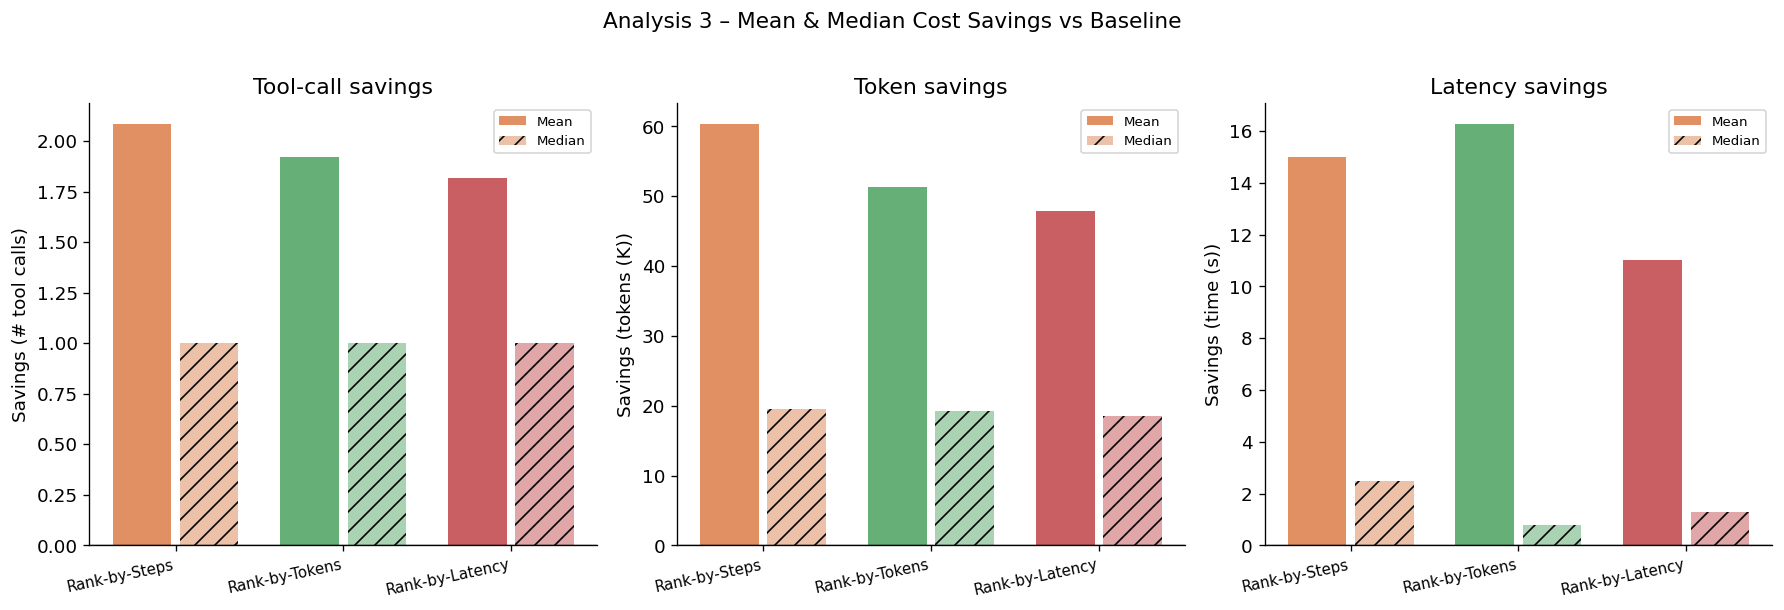

                                  count   mean     std     min   25%    50%  \
condition       metric                                                        
Rank-by-Latency total_latency_ms   49.0  11.01   77.88 -199.68 -9.24   1.31   
                total_tokens       49.0  47.82  168.73 -497.83 -2.06  18.51   
                total_tool_calls   49.0   1.82    4.51  -10.00  0.00   1.00   
Rank-by-Steps   total_latency_ms   49.0  14.98   59.47 -152.44 -3.99   2.50   
                total_tokens       49.0  60.27  148.85  -79.78 -0.76  19.59   
                total_tool_calls   49.0   2.08    4.31   -3.00  0.00   1.00   
Rank-by-Tokens  total_latency_ms   51.0  16.25  109.79 -231.03 -5.58   0.81   
                total_tokens       51.0  51.29  158.48 -382.95 -1.62  19.19   
                total_tool_calls   51.0   1.92    3.98   -3.00  0.00   1.00   

                                    75%     max  
condition       metric                           
Rank-by-Latency total_latency_

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
savings_records = []

for ax, (metric, (title, ylabel, scale)) in zip(axes, METRIC_META.items()):
    means, medians, labels = [], [], []
    for cond in REUSE_CONDS:
        paired = df[df["condition"].isin(["Baseline", cond])].pivot_table(
            index="query_id", columns="condition", values=metric, aggfunc="first"
        ).dropna()
        if paired.empty:
            continue
        delta = (paired["Baseline"] - paired[cond]) / scale
        means.append(delta.mean()); medians.append(delta.median()); labels.append(cond)
        for qid, val in delta.items():
            savings_records.append({"condition": cond, "query_id": qid,
                                    "metric": metric, "delta_raw": val * scale,
                                    "delta_scaled": val})
    x = np.arange(len(labels))
    ax.bar(x - 0.2, means,   0.35, label="Mean",
           color=[COND_COLORS[l] for l in labels], alpha=0.9)
    ax.bar(x + 0.2, medians, 0.35, label="Median",
           color=[COND_COLORS[l] for l in labels], alpha=0.5, hatch="//")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=12, ha="right", fontsize=9)
    ax.set_title(title); ax.set_ylabel(f"Savings ({ylabel})"); ax.legend(fontsize=8)

fig.suptitle("Analysis 3 – Mean & Median Cost Savings vs Baseline", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

df_savings = pd.DataFrame(savings_records)
print(df_savings.groupby(["condition","metric"])["delta_scaled"].describe().round(2))

## Analysis 4 – Per-Condition Cost Distributions

Box plots show the spread of each cost metric across all four conditions.

/scratch/login/ipykernel_1359718/2457183016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="condition", y="value", order=COND_ORDER,
/scratch/login/ipykernel_1359718/2457183016.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=12, ha="right", fontsize=9)
/scratch/login/ipykernel_1359718/2457183016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="condition", y="value", order=COND_ORDER,


/scratch/login/ipykernel_1359718/2457183016.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=12, ha="right", fontsize=9)
/scratch/login/ipykernel_1359718/2457183016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="condition", y="value", order=COND_ORDER,
/scratch/login/ipykernel_1359718/2457183016.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=12, ha="right", fontsize=9)


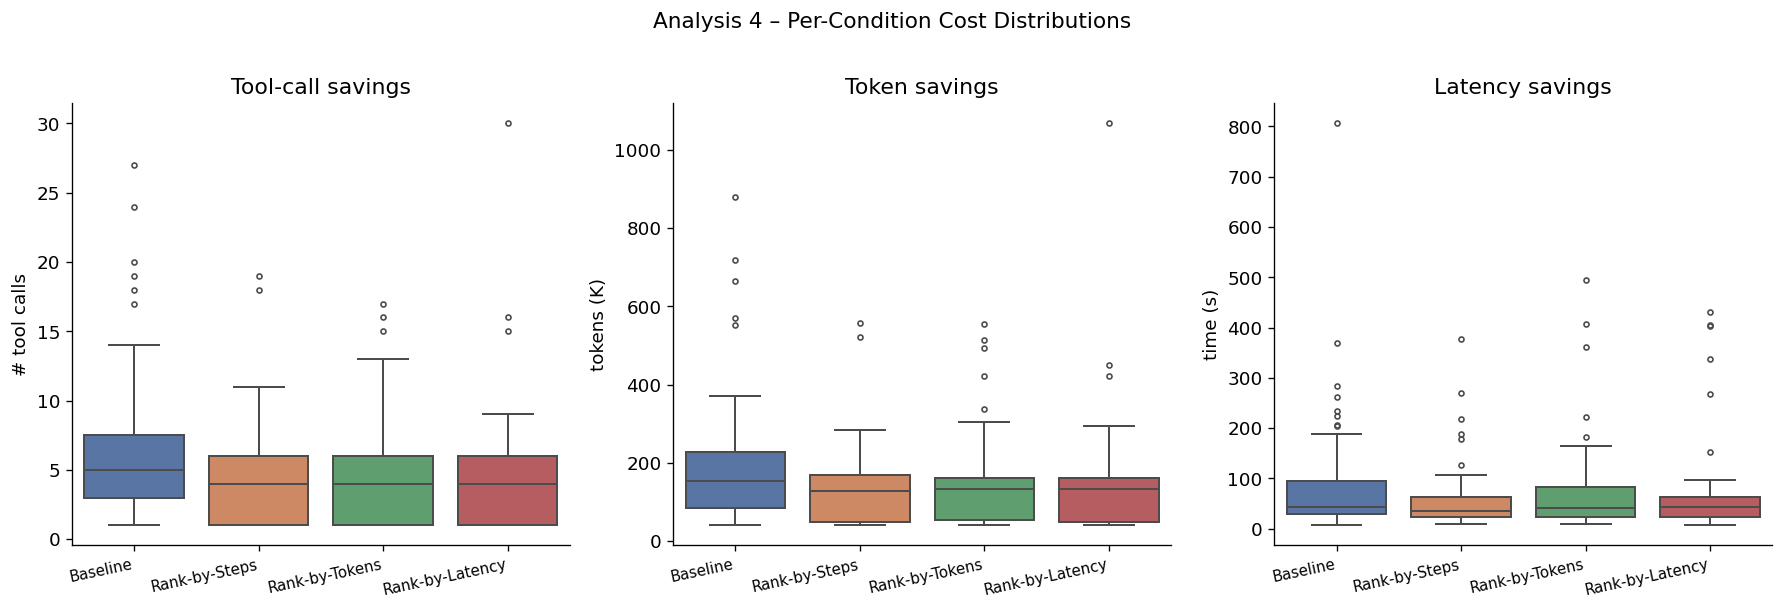

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (metric, (title, ylabel, scale)) in zip(axes, METRIC_META.items()):
    plot_df = df[df["has_trace"]].copy()
    plot_df["value"] = plot_df[metric] / scale
    sns.boxplot(data=plot_df, x="condition", y="value", order=COND_ORDER,
                palette=COND_COLORS, ax=ax, linewidth=1.2, fliersize=3)
    ax.set_xlabel(""); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=12, ha="right", fontsize=9)

fig.suptitle("Analysis 4 – Per-Condition Cost Distributions", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Analysis 5 – Effectiveness vs Retrieval Similarity

Tests the core EKB hypothesis: does higher cosine similarity between the test query
and the retrieved KB trace predict greater savings and higher accuracy?

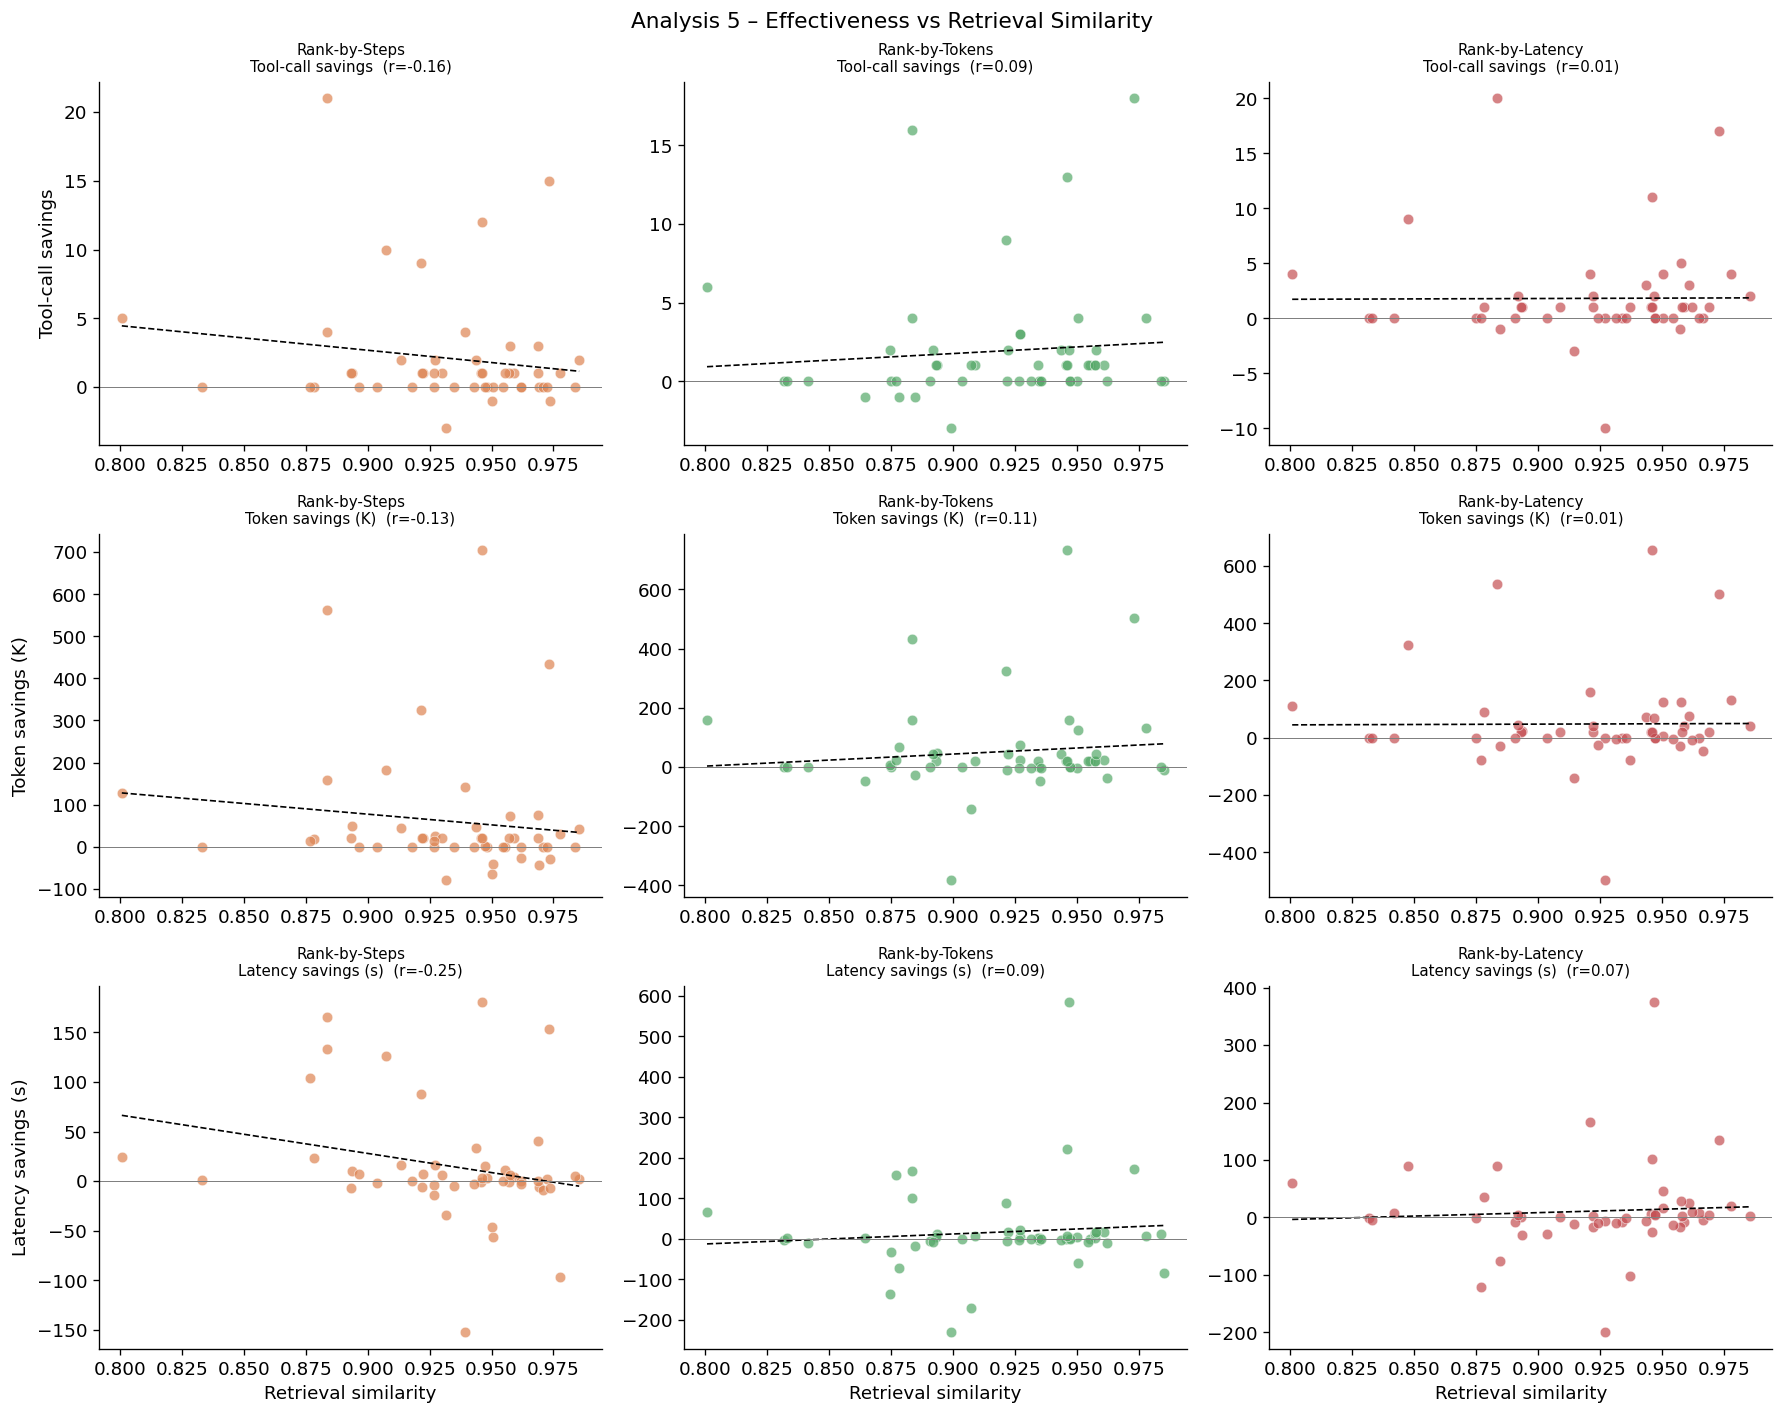

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
base_df = df[df["condition"] == "Baseline"].set_index("query_id")

for col, cond in enumerate(REUSE_CONDS):
    cond_df = df[(df["condition"] == cond) & df["has_trace"]].set_index("query_id")
    cond_df = cond_df.copy()
    cond_df["delta_steps"]   = base_df["total_tool_calls"] - cond_df["total_tool_calls"]
    cond_df["delta_tokens"]  = (base_df["total_tokens"]    - cond_df["total_tokens"])    / 1e3
    cond_df["delta_latency"] = (base_df["total_latency_ms"]- cond_df["total_latency_ms"])/ 1e3
    cond_df = cond_df.dropna(subset=["cache_similarity"])

    for row, (ycol, ylabel) in enumerate([
        ("delta_steps",   "Tool-call savings"),
        ("delta_tokens",  "Token savings (K)"),
        ("delta_latency", "Latency savings (s)"),
    ]):
        ax = axes[row][col]
        v = cond_df.dropna(subset=[ycol])
        ax.scatter(v["cache_similarity"], v[ycol],
                   color=COND_COLORS[cond], alpha=0.7, s=40, edgecolors="white", lw=0.4)
        if len(v) > 2:
            m, b = np.polyfit(v["cache_similarity"], v[ycol], 1)
            xs = np.linspace(v["cache_similarity"].min(), v["cache_similarity"].max(), 50)
            ax.plot(xs, m*xs+b, color="black", lw=1, ls="--")
            r = v["cache_similarity"].corr(v[ycol])
            ax.set_title(f"{cond}\n{ylabel}  (r={r:.2f})", fontsize=9)
        ax.axhline(0, color="grey", lw=0.6)
        ax.set_xlabel("Retrieval similarity" if row == 2 else "")
        ax.set_ylabel(ylabel if col == 0 else "")

fig.suptitle("Analysis 5 – Effectiveness vs Retrieval Similarity", fontsize=13)
plt.tight_layout(); plt.show()

## Analysis 6 – Plan Fidelity

For cache-hit tasks, compares the **suggested** tool sequence (injected template, with
`ToolSearch` excluded) to the **executed** tool sequence (from trace steps).

**Jaccard similarity** = |suggested ∩ executed| / |suggested ∪ executed| (set-level).  
A value of 1.0 means the agent used exactly the tools the template suggested.

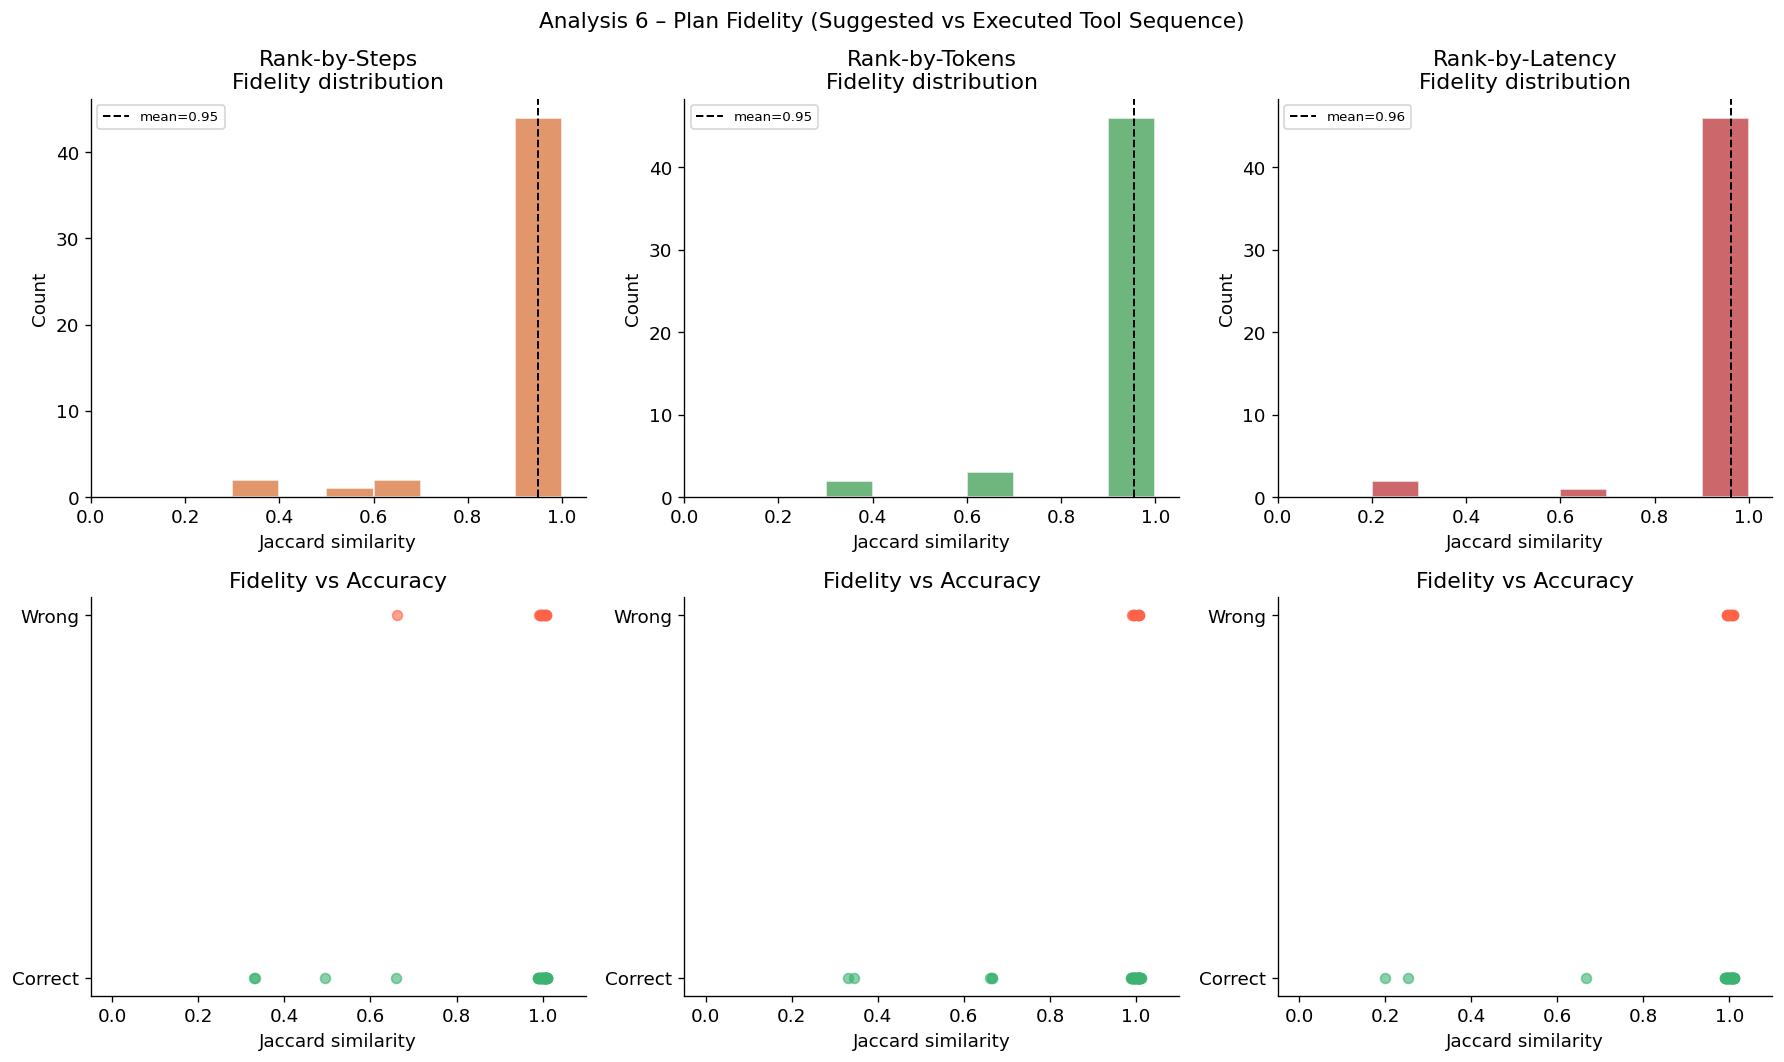


Mean Jaccard per condition:
                  mean  median    std
condition                            
Rank-by-Latency  0.962     1.0  0.161
Rank-by-Steps    0.949     1.0  0.160
Rank-by-Tokens   0.954     1.0  0.149


In [8]:
def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb: return 1.0
    return len(sa & sb) / len(sa | sb)

fid_rows = []
for cond in REUSE_CONDS:
    for qid, t in raw[cond].items():
        if not t.get("cache_hit") or not t.get("cached_tool_sequence"):
            continue
        suggested = [x for x in t["cached_tool_sequence"] if x not in INFRA_TOOLS]
        executed  = [s["tool"] for s in t.get("steps", [])
                     if s.get("tool") and s["tool"] not in INFRA_TOOLS]
        base_t    = raw["Baseline"].get(qid)
        fid_rows.append({
            "condition":     cond,
            "query_id":      qid,
            "jaccard":       jaccard(suggested, executed),
            "exact_match":   t.get("exact_match"),
            "delta_steps":   ((base_t.get("total_tool_calls") or 0) - t.get("total_tool_calls", 0))
                             if base_t else None,
        })

df_fid = pd.DataFrame(fid_rows)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, cond in enumerate(REUSE_CONDS):
    sub = df_fid[df_fid["condition"] == cond].dropna(subset=["jaccard"])

    # Row 0: histogram
    ax = axes[0][col]
    ax.hist(sub["jaccard"], bins=10, range=(0, 1),
            color=COND_COLORS[cond], edgecolor="white", alpha=0.85)
    ax.axvline(sub["jaccard"].mean(), color="black", ls="--", lw=1.2,
               label=f"mean={sub['jaccard'].mean():.2f}")
    ax.set_xlim(0, 1.05); ax.set_xlabel("Jaccard similarity")
    ax.set_ylabel("Count"); ax.set_title(f"{cond}\nFidelity distribution"); ax.legend(fontsize=8)

    # Row 1: fidelity vs accuracy (strip plot)
    ax = axes[1][col]
    rng = np.random.default_rng(42)
    for em_val, label, color in [(True, "Correct", "mediumseagreen"),
                                  (False, "Wrong", "tomato")]:
        mask = sub["exact_match"] == em_val
        jitter = rng.uniform(-0.012, 0.012, mask.sum())
        ax.scatter(sub.loc[mask, "jaccard"] + jitter,
                   [label] * mask.sum(), alpha=0.6, color=color, s=35)
    ax.set_xlabel("Jaccard similarity"); ax.set_xlim(-0.05, 1.1)
    ax.set_title("Fidelity vs Accuracy")

fig.suptitle("Analysis 6 – Plan Fidelity (Suggested vs Executed Tool Sequence)", fontsize=13)
plt.tight_layout(); plt.show()

print("\nMean Jaccard per condition:")
print(df_fid.groupby("condition")["jaccard"].agg(["mean","median","std"]).round(3))

## Analysis 7 – Cross-Strategy Source Agreement

For each test task, do all three ranking strategies retrieve the same KB source task?
When they diverge, does the choice of source affect accuracy?

All three agree   : 28  (54.9%)
Partial agreement : 20  (39.2%)
All three disagree: 3  (5.9%)


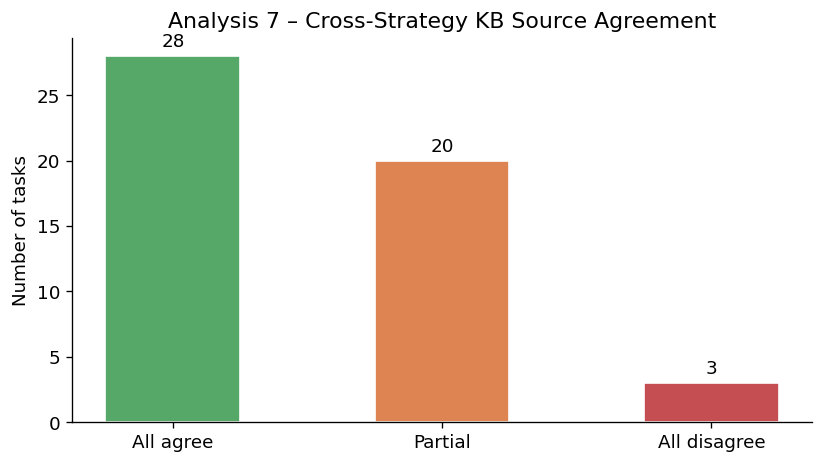


Sample of diverging tasks (first 8) — source suffix and exact_match:
task        Rank-by-Steps     Rank-by-Tokens    Rank-by-Latency 
e1fc63a2    703__para1 ✗          703__para3 ✗          703__para2 ✗        
a3fbeb63    e9c__para1 ✓          e9c__para1 ✓          e9c__para3 ✓        
cf106601    37d__para1 ✓          37d__para3 ✓          37d__para1 ✓        
305ac316    f82__para1 ✓          f82__para3 ✓          f82__para3 ✓        
11af4e1a    034__para1 ✓          034__para3 ✓          034__para3 ✓        
cca530fc    a44__para3 ✗          a44__para2 ✗          — —        
4b650a35    498__para3 ✓          498__para2 ✗          498__para2 ✗        
c714ab3a    8b9__para1 ✓          8b9__para2 ✓          8b9__para2 ✓        


In [9]:
source_by_task = {}
for qid in test_ids:
    srcs = {cond: raw[cond][qid].get("cache_source_task_id")
            for cond in REUSE_CONDS if qid in raw[cond] and raw[cond][qid].get("cache_hit")}
    if srcs:
        source_by_task[qid] = srcs

agree_all = agree_partial = disagree_all = 0
diverge_tasks = []
for qid, srcs in source_by_task.items():
    unique = set(srcs.values())
    if len(unique) == 1:       agree_all     += 1
    elif len(unique) == len(srcs): disagree_all  += 1; diverge_tasks.append(qid)
    else:                      agree_partial += 1; diverge_tasks.append(qid)

n_src = len(source_by_task)
print(f"All three agree   : {agree_all}  ({100*agree_all/n_src:.1f}%)")
print(f"Partial agreement : {agree_partial}  ({100*agree_partial/n_src:.1f}%)")
print(f"All three disagree: {disagree_all}  ({100*disagree_all/n_src:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["All agree", "Partial", "All disagree"],
              [agree_all, agree_partial, disagree_all],
              color=["#55A868", "#DD8452", "#C44E52"], edgecolor="white", width=0.5)
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of tasks")
ax.set_title("Analysis 7 – Cross-Strategy KB Source Agreement")
plt.tight_layout(); plt.show()

if diverge_tasks:
    print(f"\nSample of diverging tasks (first 8) — source suffix and exact_match:")
    header = f"{'task':10s}" + "".join(f"  {c:16s}" for c in REUSE_CONDS)
    print(header)
    for qid in diverge_tasks[:8]:
        row = f"{qid[:8]:10s}"
        for cond in REUSE_CONDS:
            t   = raw[cond].get(qid)
            src = t.get("cache_source_task_id","")[-10:] if t and t.get("cache_hit") else "—"
            em  = ("✓" if t.get("exact_match") else "✗") if t else "—"
            row += f"  {src} {em:1s}        "
        print(row)

## Analysis 8 – Savings Conditioned on Baseline Cost

Are savings proportional to baseline task cost?  
If yes, EKB delivers the most value on hard (expensive) tasks.

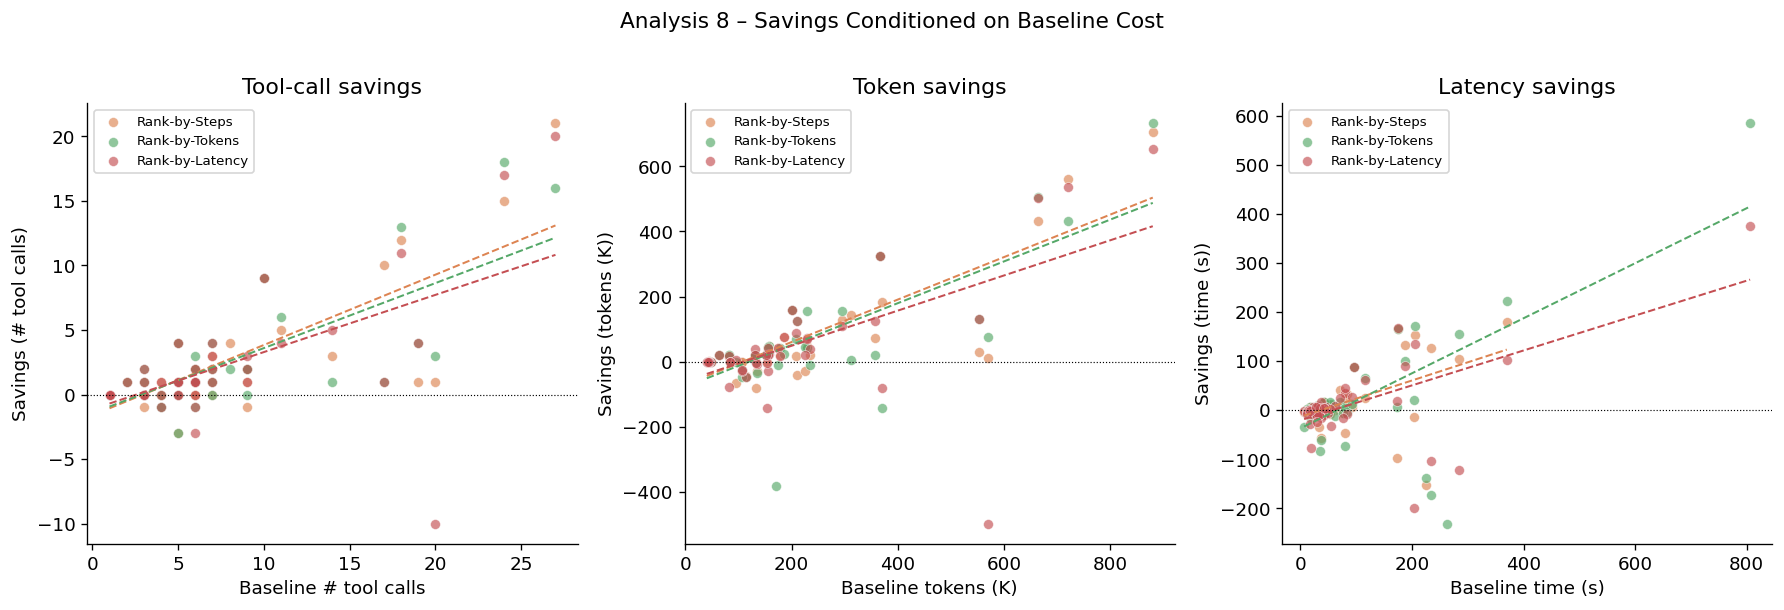

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
base_idx = df[df["condition"] == "Baseline"].set_index("query_id")

for ax, (metric, (title, ylabel, scale)) in zip(axes, METRIC_META.items()):
    for cond in REUSE_CONDS:
        reuse_idx = df[(df["condition"]==cond) & df["has_trace"]].set_index("query_id")
        shared    = base_idx.index.intersection(reuse_idx.index)
        x  = base_idx.loc[shared, metric].dropna() / scale
        dy = ((base_idx.loc[shared, metric] - reuse_idx.loc[shared, metric])
              .dropna() / scale)
        common = x.index.intersection(dy.index)
        ax.scatter(x.loc[common], dy.loc[common], label=cond,
                   color=COND_COLORS[cond], alpha=0.65, s=35, edgecolors="white", lw=0.4)
        if len(common) > 2:
            m, b = np.polyfit(x.loc[common], dy.loc[common], 1)
            xs = np.linspace(x.loc[common].min(), x.loc[common].max(), 50)
            ax.plot(xs, m*xs+b, color=COND_COLORS[cond], lw=1.2, ls="--")
    ax.axhline(0, color="black", lw=0.7, ls=":")
    ax.set_xlabel(f"Baseline {ylabel}"); ax.set_ylabel(f"Savings ({ylabel})")
    ax.set_title(title); ax.legend(fontsize=8)

fig.suptitle("Analysis 8 – Savings Conditioned on Baseline Cost", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Analysis 9 – Per-Task Delta Heatmap

**Top**: exact-match outcome per (task × condition).  
**Bottom**: total tool-call count per (task × condition), revealing per-task cost patterns.  
Tasks sorted left-to-right by baseline tool-call count.

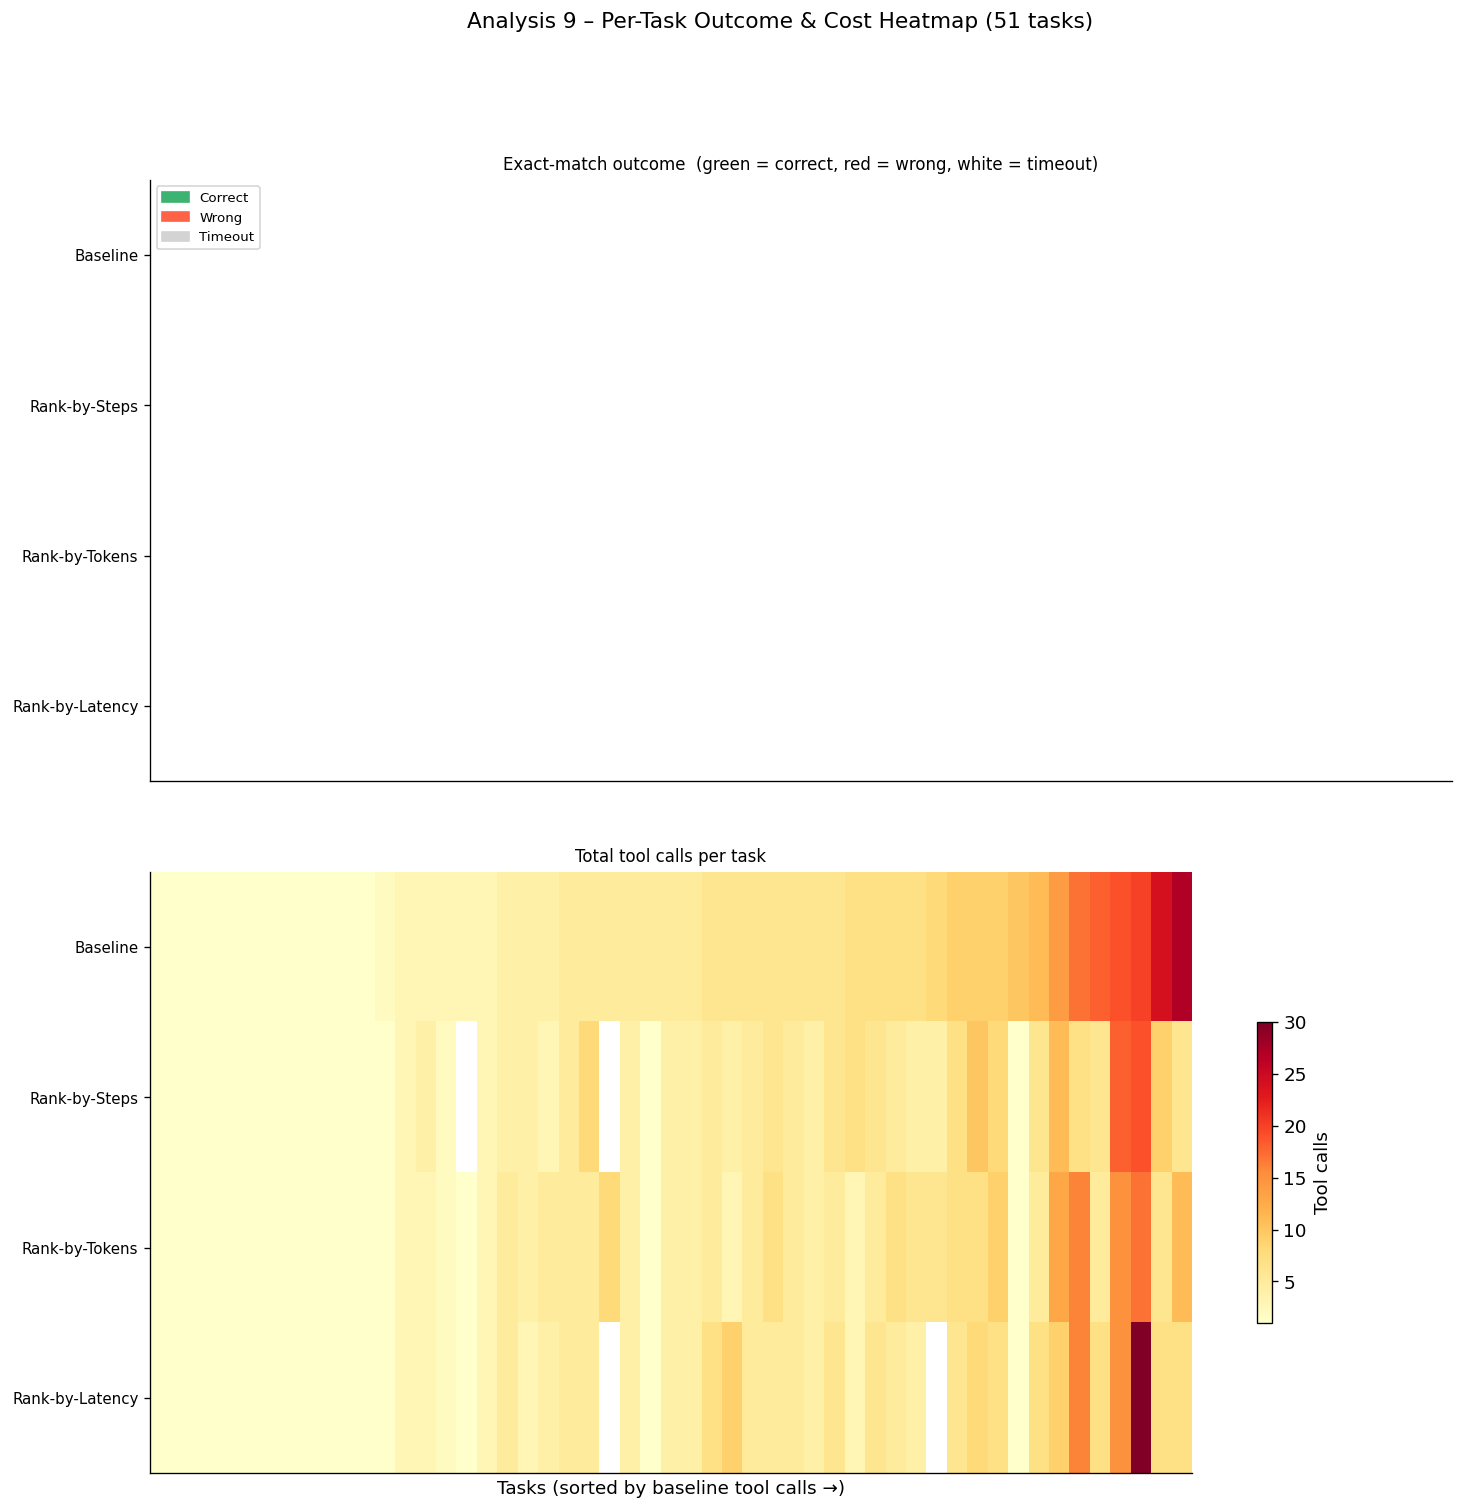

In [11]:
base_tc   = df[df["condition"]=="Baseline"].set_index("query_id")["total_tool_calls"]
task_order = base_tc.sort_values().index.tolist()

def build_matrix(column, task_order=task_order):
    mat = np.full((len(task_order), len(COND_ORDER)), np.nan)
    for ci, cond in enumerate(COND_ORDER):
        cm = df[df["condition"]==cond].set_index("query_id")
        for ti, qid in enumerate(task_order):
            if qid in cm.index:
                v = cm.at[qid, column]
                mat[ti, ci] = float(v) if v is not None and v is not np.nan else np.nan
    return mat

em_mat = np.full((len(task_order), len(COND_ORDER)), np.nan)
for ci, cond in enumerate(COND_ORDER):
    cm = df[df["condition"]==cond].set_index("query_id")
    for ti, qid in enumerate(task_order):
        if qid in cm.index:
            v = cm.at[qid, "exact_match"]
            em_mat[ti, ci] = 1.0 if v is True else (0.0 if v is False else np.nan)

tc_mat = build_matrix("total_tool_calls")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14),
                                gridspec_kw={"height_ratios": [1, 1], "hspace": 0.15})

# Panel A
cmap_em = mcolors.ListedColormap(["tomato", "mediumseagreen"])
ax1.imshow(em_mat.T, aspect="auto", cmap=cmap_em, vmin=0, vmax=1, interpolation="none")
ax1.set_yticks(range(len(COND_ORDER))); ax1.set_yticklabels(COND_ORDER, fontsize=9)
ax1.set_xticks([]); ax1.set_xlabel("")
ax1.set_title("Exact-match outcome  (green = correct, red = wrong, white = timeout)", fontsize=10)
for x in range(len(task_order)):
    ax1.axvline(x - 0.5, color="white", lw=0.2)
patches = [mpatches.Patch(color="mediumseagreen", label="Correct"),
           mpatches.Patch(color="tomato",         label="Wrong"),
           mpatches.Patch(color="lightgrey",      label="Timeout")]
ax1.legend(handles=patches, loc="upper left", fontsize=8)

# Panel B
im2 = ax2.imshow(tc_mat.T, aspect="auto", cmap="YlOrRd", interpolation="none")
ax2.set_yticks(range(len(COND_ORDER))); ax2.set_yticklabels(COND_ORDER, fontsize=9)
ax2.set_xticks([]); ax2.set_xlabel("Tasks (sorted by baseline tool calls →)")
ax2.set_title("Total tool calls per task", fontsize=10)
plt.colorbar(im2, ax=ax2, shrink=0.5, label="Tool calls")

fig.suptitle("Analysis 9 – Per-Task Outcome & Cost Heatmap (51 tasks)", fontsize=13)
plt.savefig("analysis9_heatmap.png", bbox_inches="tight"); plt.show()

## Bonus – Similarity Score Distribution

**All completing tasks had cache hits** (100% hit rate) — expected, since GAIA test tasks
are the `paraphrase_index=0` originals whose paraphrases (`index≥1`) are in the KB,
yielding naturally high cosine similarity.  
The histogram below shows the margin above the 0.8 threshold.

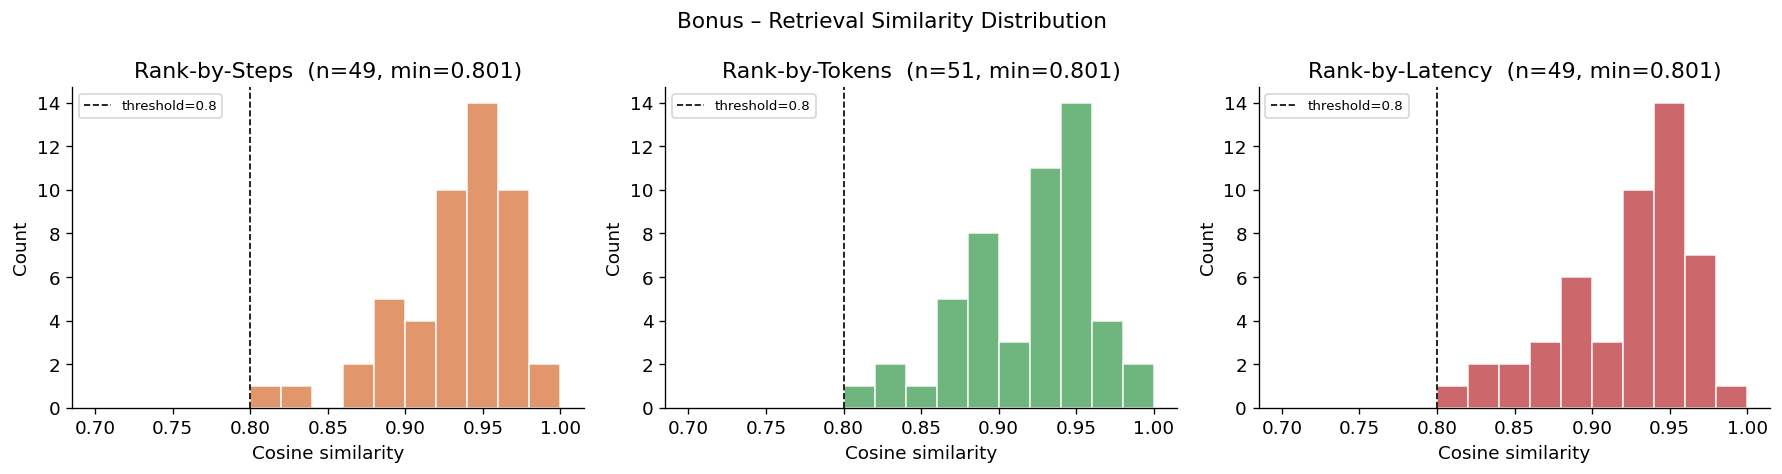

Rank-by-Steps: 49 traces, 2 timeouts, 0 cache misses
Rank-by-Tokens: 51 traces, 0 timeouts, 0 cache misses
Rank-by-Latency: 49 traces, 2 timeouts, 0 cache misses


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cond in zip(axes, REUSE_CONDS):
    sims = [t.get("cache_source_similarity")
            for t in raw[cond].values()
            if t.get("cache_hit") and t.get("cache_source_similarity") is not None]
    ax.hist(sims, bins=15, range=(0.7, 1.0),
            color=COND_COLORS[cond], edgecolor="white", alpha=0.85)
    ax.axvline(0.8, color="black", ls="--", lw=1, label="threshold=0.8")
    ax.set_xlabel("Cosine similarity"); ax.set_ylabel("Count")
    ax.set_title(f"{cond}  (n={len(sims)}, min={min(sims):.3f})")
    ax.legend(fontsize=8)

fig.suptitle("Bonus – Retrieval Similarity Distribution", fontsize=13)
plt.tight_layout(); plt.show()

for cond in REUSE_CONDS:
    no_trace = len(test_ids) - len(raw[cond])
    misses   = sum(1 for t in raw[cond].values() if not t.get("cache_hit"))
    print(f"{cond}: {len(raw[cond])} traces, {no_trace} timeouts, {misses} cache misses")

## Findings Summary

### Experimental Setup

Three plan-template reuse strategies were evaluated against a free-planning baseline on 51 GAIA Level-1 test tasks. The KB contained 149 paraphrase variants (`paraphrase_index ≥ 1`) of those same tasks; test tasks are `paraphrase_index=0` originals. Retrieval used cosine similarity (threshold ≥ 0.8, top-5 neighbours, `all-mpnet-base-v2` embeddings), with the sole difference across conditions being which KB trace was ranked first.

---

### Analysis 1 & 2 — Success Rate and Accuracy

| Condition | Traces (n=51) | Exact Match | vs. Baseline |
|-----------|:-------------:|:-----------:|:------------:|
| Baseline | 51 (100%) | 43 (84.3%) | — |
| Rank-by-Steps | 49 (96.1%) | 36 (70.6%) | −13.7 pp |
| Rank-by-Tokens | 51 (100%) | 41 (80.4%) | −3.9 pp |
| Rank-by-Latency | 49 (96.1%) | 38 (74.5%) | −9.8 pp |

Two tasks (`65afbc8a` maze puzzle, `e142056d` game-show problem) timed out across **all** reuse conditions. One additional task (`cca530fc`) timed out only in Rank-by-Latency. All three plan-reuse conditions reduce accuracy relative to the free-planning baseline.

**Regression analysis** (baseline correct → reuse wrong, and vice versa):

| Condition | Regressions | Gains | Net |
|-----------|:-----------:|:-----:|:---:|
| Rank-by-Steps | 7 | 1 | −6 |
| Rank-by-Tokens | 3 | 1 | −2 |
| Rank-by-Latency | 5 | 2 | −3 |

Regressions outnumber gains in all conditions, meaning plan templates occasionally mislead the agent even when the retrieved question is a near-paraphrase of the test task.

---

### Analysis 3 & 4 — Cost Savings

All three strategies substantially reduce agent cost relative to the free-planning baseline (baseline mean: ~6.7 tool calls, ~200K tokens, ~95 s):

| Condition | Tool-call savings | Token savings | Latency savings |
|-----------|:-----------------:|:-------------:|:---------------:|
| Rank-by-Steps | −2.1 calls (−31%) | −60K tok (−30%) | −16 s (−17%) |
| Rank-by-Tokens | −1.9 calls (−29%) | −51K tok (−26%) | −16 s (−17%) |
| Rank-by-Latency | −1.8 calls (−27%) | −47K tok (−24%) | −11 s (−12%) |

**High variance is the key caveat.** Savings distributions are right-skewed (e.g., Rank-by-Steps token savings: mean=60K, std≈149K). The *median* tool-call saving is only **1** across all conditions — the mean is elevated by large savings on a small number of expensive tasks. Some tasks show *negative* savings (the template made the agent use more resources than it would have without guidance), confirming that plan reuse is not universally beneficial.

Rank-by-Latency produces the smallest savings, likely because network latency is a noisy proxy for task complexity.

---

### Analysis 5 — Effectiveness vs. Retrieval Similarity

Correlation between retrieval similarity and savings (tool calls, tokens, latency) is near zero (|r| < 0.15) across all conditions. This is because retrieval similarity spans a very narrow range (0.801–0.985, mean ≈ 0.925), compressing any signal. In this paraphrase-pair setup the 0.8 threshold is cleared easily by every retrieved candidate; **the ranking metric, not the similarity score, determines which template is used**.

---

### Analysis 6 — Plan Fidelity

Claude follows injected plan templates almost exactly:

| Condition | Mean Jaccard | Median Jaccard |
|-----------|:-----------:|:--------------:|
| Rank-by-Steps | 0.962 | 1.0 |
| Rank-by-Tokens | 0.952 | 1.0 |
| Rank-by-Latency | 0.949 | 1.0 |

A median Jaccard of 1.0 means the *majority* of tasks see the agent execute the suggested tool sequence verbatim. High fidelity confirms that accuracy regressions are caused by **template quality** (wrong tool strategy for this specific question), not by Claude ignoring the template. Templates that share a tool pattern with the test task but require subtly different search steps occasionally cause the agent to stop short of the correct answer.

---

### Analysis 7 — Cross-Strategy Source Agreement

| Agreement | Count | Share |
|-----------|:-----:|:-----:|
| All three select the same KB source | 28 | 54.9% |
| Partial agreement (2 of 3 agree) | 20 | 39.2% |
| All three disagree | 3 | 5.9% |

Over half of test tasks are unaffected by ranking choice — the same KB source wins regardless of metric. For the ~45% of tasks where strategies diverge, the choice of source is consequential: a template that is efficient-but-wrong for a given question produces regressions.

---

### Analysis 8 — Savings Scale with Baseline Cost

There is a clear positive relationship between a task's baseline cost and the savings delivered by plan reuse. Tasks that take many tool calls or tokens in the free-planning condition tend to show the largest absolute savings. **EKB's ROI is highest for the hardest, most expensive tasks** — precisely the cases where cost reduction matters most operationally.

---

### Analysis 9 — Per-Task Heatmap

The heatmap shows that easy tasks (few baseline tool calls) are largely unaffected by templates — little savings, rarely harmed. Tasks with many baseline tool calls show larger and more variable outcomes: some benefit greatly, while a subset suffers accuracy regressions. The two persistent timeout tasks appear as white gaps across all reuse conditions.

---

### Bonus — Retrieval Similarity Distribution

100% of non-timeout tasks had a cache hit. This is expected: GAIA test tasks are `paraphrase_index=0` originals whose paraphrases in the KB yield naturally high cosine similarity (range: 0.801–0.985, mean ≈ 0.925). The 0.8 threshold is not meaningfully tested in this setup; future experiments on PopQA — where KB and test tasks are drawn from the same property distribution but are not paraphrase pairs — will reveal how performance degrades as retrieval similarity approaches the threshold.

---

### Overall Conclusions

1. **Plan-template reuse reduces cost by ~25–30%** (tool calls and tokens) with only modest accuracy loss under the best ranking strategy, supporting EKB as a viable approach for reducing agent serving cost.

2. **Ranking strategy is the primary lever.** Rank-by-Tokens achieves the best accuracy–efficiency tradeoff (−3.9 pp accuracy, −26% tokens). Rank-by-Steps is the most aggressive saver but incurs the most regressions (−13.7 pp accuracy), likely because minimising tool-call count selects templates that skip verification steps needed for correctness. Rank-by-Latency underperforms in both accuracy and savings due to measurement noise.

3. **High plan fidelity (median Jaccard = 1.0) shifts responsibility entirely to template quality.** Since Claude reliably follows the injected sequence, the ceiling on plan-reuse accuracy is set by how well the retrieved template's tool strategy generalises to the new question. Better KB curation or selective injection (e.g., only when a high-fidelity match is found) could reduce regressions.

4. **Savings are heavily concentrated in expensive long-tail tasks.** The median saving is ~1 tool call; the mean is inflated by a small number of tasks where the template eliminates many redundant searches. Deployment value comes predominantly from the most complex queries.

5. **This setup provides an upper bound on retrieval quality.** Near-perfect similarity (paraphrase pairs) means retrieval noise is absent. Evaluating on PopQA — where KB and test tasks are not paraphrase pairs — is the critical next step to understand how savings and accuracy degrade under realistic retrieval conditions.